In [1]:
#Delete for submission
import os
from pathlib import Path

# Automatically searches for the CSV files from your home directory
csv_files = list(Path.home().rglob('Resale Flat Prices*.csv'))

if csv_files:
    os.chdir(csv_files[0].parent)
    print(f"Found files in: {os.getcwd()}")
else:
    print("CSV files not found!")

Found files in: C:\Users\Andre\Downloads


<pre style="border: 1px solid #ccc; padding: 10px;">
<h1>Library Importing</h1>
</pre>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import glob
import warnings
import datetime as dt
warnings.filterwarnings('ignore')


plt.rcParams['figure.figsize'] = (11, 5)
sns.set_style('whitegrid')


print("✅ Libraries loaded")

✅ Libraries loaded


<pre style="border: 1px solid #ccc; padding: 10px;">
<h1>Data Exploration & Cleaning</h1>
</pre>

## Loading & Exploring

`Load & Explore real Singapore housing data`

### Load & Inspect

In [3]:
# Load the data from multiple CSV files
files = glob.glob('Resale Flat Prices*.csv')
print(f"Found {len(files)} CSV files: {files}")
hdb_raw = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

Found 1 CSV files: ['Resale Flat Prices (Based on Approval Date), 1990 - 1999.csv']


EmptyDataError: No columns to parse from file

In [ ]:
# Inspect data shape, types, and preview after loading

print("📊 Data Overview:\n")
print(f"Total rows loaded: {len(hdb_raw):,}")
print(f"Total columns:     {hdb_raw.shape[1]}")

print("\nData types:")
print(hdb_raw.dtypes)
print("\nFirst 5 rows:")
print(hdb_raw.head())

📊 Data Overview:

Total rows loaded: 972,105
Total columns:     11

Data types:
month                   object
town                    object
flat_type               object
block                   object
street_name             object
storey_range            object
floor_area_sqm         float64
flat_model              object
lease_commence_date      int64
resale_price           float64
remaining_lease         object
dtype: object

First 5 rows:
     month        town flat_type block       street_name storey_range  \
0  1990-01  ANG MO KIO    1 ROOM   309  ANG MO KIO AVE 1     10 TO 12   
1  1990-01  ANG MO KIO    1 ROOM   309  ANG MO KIO AVE 1     04 TO 06   
2  1990-01  ANG MO KIO    1 ROOM   309  ANG MO KIO AVE 1     10 TO 12   
3  1990-01  ANG MO KIO    1 ROOM   309  ANG MO KIO AVE 1     07 TO 09   
4  1990-01  ANG MO KIO    3 ROOM   216  ANG MO KIO AVE 1     04 TO 06   

   floor_area_sqm      flat_model  lease_commence_date  resale_price  \
0            31.0        IMPROVED      

---
## Data Cleaning

`Clean & Process messy real-world data professionally.`

### Filter Data

In [ ]:
# Convert 'month' column from string to datetime format
hdb_raw['month'] = pd.to_datetime(hdb_raw['month'], format='%Y-%m')

# Apply chosen date range filter (2012-2023)
start_date = '2012-01-01'
end_date = '2023-12-31'

# Filter the dataset to include only records within the specified date range
hdb = hdb_raw[(hdb_raw['month'] >= start_date) & (hdb_raw['month'] <= end_date)].copy()

# Display the number of rows after applying the date filter and explain the reason for choosing this range
print(f"After date filter ({start_date} to {end_date}): {len(hdb):,} rows")
print(f"Reason we chose this range: This 12-year period was chosen because the dataset from 2012 onwards uses a consistent registration-date recording system, which reduces inconsistencies and simplifies data cleaning and preprocessing. It also captures a complete housing market cycle, including the peak before cooling measures, the stabilisation period, and the sharp resale price increase after COVID-19. Using recent years ensures the data is relevant, consistent, and large enough for meaningful analysis without unnecessary complexity.")

After date filter (2012-01-01 to 2023-12-31): 261,694 rows
Reason we chose this range: This 12-year period was chosen because the dataset from 2012 onwards uses a consistent registration-date recording system, which reduces inconsistencies and simplifies data cleaning and preprocessing. It also captures a complete housing market cycle, including the peak before cooling measures, the stabilisation period, and the sharp resale price increase after COVID-19. Using recent years ensures the data is relevant, consistent, and large enough for meaningful analysis without unnecessary complexity.


### Drop Duplicates

In [ ]:
# Identify number of rows in dataset before removing duplicates
rows_before = len(hdb)

# Remove duplicating rows in dataset
hdb.drop_duplicates(inplace=True)

# Identify number of rows in dataset after removing duplicates
rows_after = len(hdb)

# Display the number of rows removed and the percentage of duplicates in the dataset
duplicates_removed = rows_before - rows_after
percentage_duplicates = (duplicates_removed / rows_before) * 100
print(f"Duplicates removed: {duplicates_removed:,} rows")
print(f"Percentage of duplicates: {percentage_duplicates:.2f}%")
print(f"Remaining rows after removing duplicates: {rows_after:,} rows")

Duplicates removed: 554 rows
Percentage of duplicates: 0.21%
Remaining rows after removing duplicates: 261,140 rows


### Handle Missing Values

In [ ]:
# Confirm missing values in filtered dataset
print("Missing values in each column:")
print(hdb.isnull().sum())

Missing values in each column:
month                      0
town                       0
flat_type                  0
block                      0
street_name                0
storey_range               0
floor_area_sqm             0
flat_model                 0
lease_commence_date        0
resale_price               0
remaining_lease        55142
dtype: int64


In [ ]:
# Drop or impute missing values using the 5% threshold rule (drop if missing values < 5%, impute with median if missing values >= 5%)
missing_threshold = 0.05 * len(hdb)

# Parse through "remaining_lease" column to convert string values to datetime, handling non-numeric entries by coercing them to NaN
hdb['remaining_lease'] = pd.to_datetime(hdb['remaining_lease'], errors='coerce')

for column in hdb.columns:
    missing_count = hdb[column].isnull().sum()
    if missing_count > 0:
        if missing_count < missing_threshold:
            hdb.dropna(subset=[column], inplace=True)
            print(f"Dropped {missing_count} rows with missing values in '{column}' (below 5% threshold).")
        else:
            median_value = hdb[column].median()
            hdb[column].fillna(median_value, inplace=True)
            print(f"Imputed {missing_count} missing values in '{column}' with median value (above 5% threshold).")

# Display the number of rows remaining after handling missing values
print(f"Rows after handling missing values: \n{len(hdb):,} rows\n")
print(f"Remaining missing values: \n{hdb.isnull().sum()}\n")

Imputed 224011 missing values in 'remaining_lease' with median value (above 5% threshold).
Rows after handling missing values: 
261,140 rows

Remaining missing values: 
month                  0
town                   0
flat_type              0
block                  0
street_name            0
storey_range           0
floor_area_sqm         0
flat_model             0
lease_commence_date    0
resale_price           0
remaining_lease        0
dtype: int64



### Remove Outliers

In [ ]:
# Using IQR method to identify and remove outliers in 'resale_price' column
Q1 = hdb['resale_price'].quantile(0.25)
Q3 = hdb['resale_price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
hdb = hdb[(hdb['resale_price'] >= lower) & (hdb['resale_price'] <= upper)]

# Using IQR method to identify and remove outliers in 'floor_area_sqm' column
Q1 = hdb['floor_area_sqm'].quantile(0.25)
Q3 = hdb['floor_area_sqm'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
hdb = hdb[(hdb['floor_area_sqm'] >= lower) & (hdb['floor_area_sqm'] <= upper)]

print(f"Outlier removal method: IQR Method")
print(f"Rows removed: {rows_before - len(hdb)}")
print(f"Rows remaining: {len(hdb):,}")
print(f"\nResale price range after cleaning:")
print(f"Min: ${hdb['resale_price'].min():,.0f}")
print(f"Max: ${hdb['resale_price'].max():,.0f}")
print(f"\nFloor area range after cleaning:")
print(f"Min: {hdb['floor_area_sqm'].min():,.0f} sqm")
print(f"Max: {hdb['floor_area_sqm'].max():,.0f} sqm")

Outlier removal method: IQR Method
Rows removed: 8153
Rows remaining: 253,541

Resale price range after cleaning:
Min: $140,000
Max: $858,137

Floor area range after cleaning:
Min: 31 sqm
Max: 169 sqm


### Parse Lease Data

In [ ]:
# Define a parsing function to convert 'remaining_lease' text to numeric years, handling various formats and missing values
def parse_lease_years(text):
    """
    Converts remaining_lease text to numeric years.
    '63 years 01 month'  → 63.08
    '45 years'           → 45.0
    '70 years 06 months' → 70.5
    """
    if pd.isna(text):
        return np.nan
    text = str(text).strip()
    years = 0
    months = 0
    if 'year' in text:
        years = int(text.split('year')[0].strip())
    if 'month' in text:
        months = int(text.split('month')[0].split()[-1].strip())
    return round(years + months / 12, 2)


# Test it:
test_cases = ['63 years 01 month', '45 years', '70 years 06 months', '99 years', None]
print("Function test:")
for t in test_cases:
    print(f"  '{t}' → {parse_lease_years(t)}")

Function test:
  '63 years 01 month' → 63.08
  '45 years' → 45.0
  '70 years 06 months' → 70.5
  '99 years' → 99.0
  'None' → nan


In [ ]:
# Apply the parsing function to the 'remaining_lease' column and create a new column 'remaining_lease_years'
hdb['remaining_lease_years'] = hdb['remaining_lease'].apply(parse_lease_years)

# Check results of parsing function
print("remaining_lease_years stats:")
print(hdb['remaining_lease_years'].describe().round(1))

# Create lease brackets for analysis; grouping data into '<50 years', '50-69 years', '70-89 years', '90+ years' based on remaining lease years
def lease_bracket(years):
    if pd.isna(years):
        return 'Unknown'
    elif years < 50:
        return '< 50 years'
    elif years < 70:
        return '50–69 years'
    elif years < 90:
        return '70–89 years'
    else:
        return '90+ years'
    
# Apply the lease_bracket function to create a new column 'lease_bracket'
hdb['lease_bracket'] = hdb['remaining_lease_years'].apply(lease_bracket)
print("\nLease bracket distribution:")
print(hdb['lease_bracket'].value_counts())

remaining_lease_years stats:
count    253541.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: remaining_lease_years, dtype: float64

Lease bracket distribution:
lease_bracket
< 50 years    253541
Name: count, dtype: int64


### Feature Engineering

In [ ]:
# Feature 1: price_per_sqm (resale price divided by floor area in sqm)
hdb['price_per_sqm'] = hdb['resale_price'] / hdb['floor_area_sqm']

# Feature 2: year
hdb['year'] = hdb['month'].dt.year

# Feature 3: region
town_to_region = {
    'BISHAN': 'Central', 'BUKIT MERAH': 'Central', 'BUKIT TIMAH': 'Central',
    'CENTRAL AREA': 'Central', 'GEYLANG': 'Central', 'KALLANG/WHAMPOA': 'Central',
    'MARINE PARADE': 'Central', 'QUEENSTOWN': 'Central', 'TOA PAYOH': 'Central',
    'BEDOK': 'East', 'PASIR RIS': 'East', 'TAMPINES': 'East',
    'SEMBAWANG': 'North', 'WOODLANDS': 'North', 'YISHUN': 'North',
    'ANG MO KIO': 'North-East', 'HOUGANG': 'North-East', 'PUNGGOL': 'North-East',
    'SENGKANG': 'North-East', 'SERANGOON': 'North-East',
    'BUKIT BATOK': 'West', 'BUKIT PANJANG': 'West', 'CHOA CHU KANG': 'West',
    'CLEMENTI': 'West', 'JURONG EAST': 'West', 'JURONG WEST': 'West',
}
hdb['region'] = hdb['town'].map(town_to_region)

# Check unmapped towns
unmapped_towns = hdb[hdb['region'].isna()]['town'].unique()
if len(unmapped_towns) > 0:
    print(f"⚠️  Add these towns to town_to_region: {', '.join(unmapped_towns)}")

# Display new columns created
print("Feature engineering complete. New columns:")
for col in ['price_per_sqm', 'year', 'region', 'remaining_lease_years', 'lease_bracket']:
     if col in hdb.columns:
         print(f"  ✅ {col}")
     else:
         print(f"  ❌ {col} — NOT YET CREATED")

Feature engineering complete. New columns:
  ✅ price_per_sqm
  ✅ year
  ✅ region
  ✅ remaining_lease_years
  ✅ lease_bracket


<pre style="border: 1px solid #ccc; padding: 10px;">
<h1>Exploratory Analysis</h1>
</pre>

## Set Up

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')


# ── Professional chart styling ───────────────────────────
plt.rcParams['figure.figsize']   = (11, 5)
plt.rcParams['axes.titlesize']   = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize']   = 11
plt.rcParams['xtick.labelsize']  = 10
plt.rcParams['ytick.labelsize']  = 10
sns.set_style('whitegrid')


# ── Consistent colour palette ────────────────────────────
C_BLUE   = '#2C3E7A'
C_RED    = '#C0392B'
C_GREEN  = '#27AE60'
C_ORANGE = '#E67E22'
C_GREY   = '#7F8C8D'
REGION_COLORS = {
    'Central':    C_RED,
    'East':       C_BLUE,
    'West':       C_GREEN,
    'North':      C_ORANGE,
    'North-East': '#8E44AD'
}


# ── Create output folder for charts ──────────────────────
os.makedirs('charts', exist_ok=True)


print('✅ Setup complete')
print('   Charts will be saved to the /charts folder')

✅ Setup complete
   Charts will be saved to the /charts folder


---
## Which town offers the best value?

> A first-time buyer has a $400,000 budget. Where should they buy?

In [14]:
# Calculate town rankings
town_value = (
    hdb.groupby('town')
    .agg(
        Median_Price_per_sqm = ('price_per_sqm', 'median'),
        Median_Resale_Price  = ('resale_price',  'median'),
        Transactions         = ('resale_price',  'count')
    )
    .round(0)
    .sort_values('Median_Price_per_sqm')
    .reset_index()
)

# Key metrics 
cheapest = town_value.iloc[0]
priciest = town_value.iloc[-1]
multiplier = priciest['Median_Price_per_sqm'] / cheapest['Median_Price_per_sqm']


print('Q1 Results: Town Rankings by Median Price per sqm')
print('=' * 60)
print(town_value.to_string(index=False))
print()
print(f'💡 Best value town:     {cheapest["town"]} — ${cheapest["Median_Price_per_sqm"]:,.0f}/sqm')
print(f'💡 Most expensive town: {priciest["town"]} — ${priciest["Median_Price_per_sqm"]:,.0f}/sqm')
print(f'💡 Price gap:           {multiplier:.1f}× more expensive per sqm')

Q1 Results: Town Rankings by Median Price per sqm
           town  Median_Price_per_sqm  Median_Resale_Price  Transactions
      WOODLANDS                3956.0             410000.0         18650
  CHOA CHU KANG                3990.0             435000.0         11618
      SEMBAWANG                4176.0             435000.0          6816
      PASIR RIS                4203.0             510000.0          8068
    JURONG WEST                4231.0             428000.0         18625
         YISHUN                4327.0             380000.0         17423
    BUKIT BATOK                4426.0             400000.0          9830
  BUKIT PANJANG                4429.0             443000.0          9504
        HOUGANG                4514.0             440000.0         12983
    JURONG EAST                4537.0             410000.0          5556
       TAMPINES                4628.0             479000.0         17746
       SENGKANG                4751.0             475000.0         19946
 

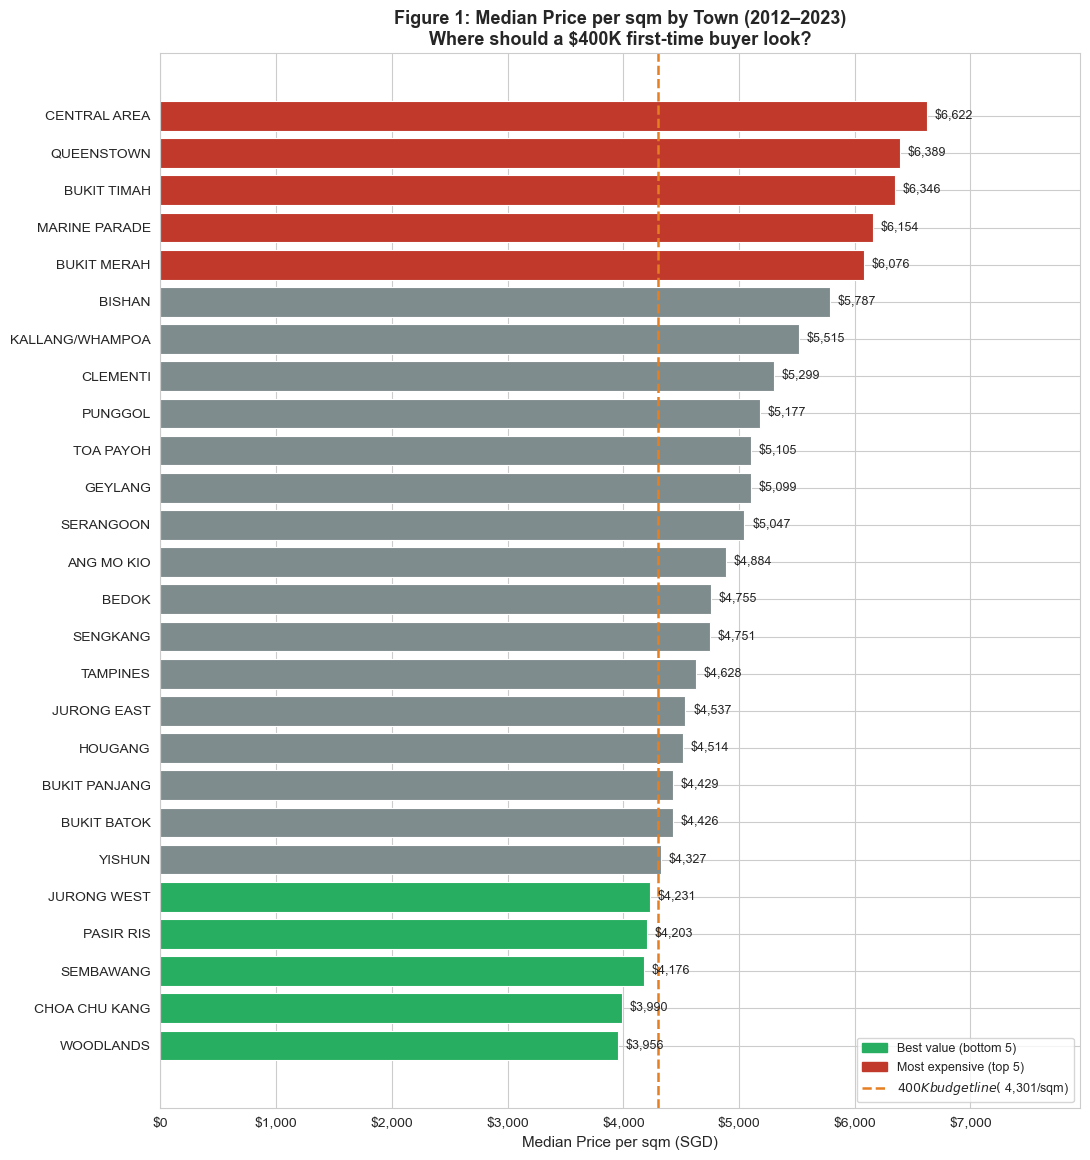

✅ Chart saved → charts/Figure1_Q1_BestValueTowns.png


In [15]:
# Chart showing top 10 cheapest and priciest towns by median price per sqm (or all towns if fewer than 15)
n_towns      = len(town_value)
n_green      = min(5, n_towns // 2)
n_red        = min(5, n_towns // 2)
bar_colors   = ([C_GREEN] * n_green
                + [C_GREY]  * (n_towns - n_green - n_red)
                + [C_RED]   * n_red)


# Budget reference line
BUDGET          = 400000
median_area     = hdb['floor_area_sqm'].median()
budget_per_sqm  = BUDGET / median_area


fig, ax = plt.subplots(figsize=(11, max(6, n_towns * 0.45)))


bars = ax.barh(
    town_value['town'],
    town_value['Median_Price_per_sqm'],
    color=bar_colors, edgecolor='white', linewidth=0.8
)


# Value labels
for bar in bars:
    ax.text(
        bar.get_width() + (town_value['Median_Price_per_sqm'].max() * 0.01),
        bar.get_y() + bar.get_height() / 2,
        f'${bar.get_width():,.0f}',
        va='center', fontsize=9
    )


# $400K threshold line
ax.axvline(budget_per_sqm, color=C_ORANGE, linestyle='--', linewidth=1.8,
           label=f'$400K ÷ {median_area:.0f}sqm = ${budget_per_sqm:,.0f}/sqm threshold')


legend_handles = [
    mpatches.Patch(color=C_GREEN,  label=f'Best value (bottom {n_green})'),
    mpatches.Patch(color=C_RED,    label=f'Most expensive (top {n_red})'),
    plt.Line2D([0], [0], color=C_ORANGE, linestyle='--', linewidth=1.8,
               label=f'$400K budget line (~${budget_per_sqm:,.0f}/sqm)'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=9)


ax.set_title(
    f'Figure 1: Median Price per sqm by Town ({hdb["year"].min()}–{hdb["year"].max()})\n'
    'Where should a $400K first-time buyer look?'
)
ax.set_xlabel('Median Price per sqm (SGD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_xlim(0, town_value['Median_Price_per_sqm'].max() * 1.20)


plt.tight_layout()
plt.savefig('charts/Figure1_Q1_BestValueTowns.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved → charts/Figure1_Q1_BestValueTowns.png')

### 📝 Q1 Written Findings

---

**Finding:**  
Among the **26** towns analysed, **Woodlands** offers the best value for buyers with a $400,000 budget, with a median price of **$3,956/sqm**. In contrast, Central Area is the most expensive at **$6,622/sqm** — approximately **1.67×** more expensive per square metre.

Towns in the **East & North** regions consistently rank as the most affordable on a per-sqm basis, while **Central** region towns command the highest prices.

**Business Recommendation:**  
First-time buyers with a $400,000 budget will get approximately **101.11 sqm** in Woodlands compared to only **60.40 sqm** in Central Area. We recommend buyers prioritise towns such as **Woodlands**, **Choa Chu Kang**, and **Sembawang** for the best value. *[Note: this analysis does not account for proximity to MRT, school zones, or flat condition.]*

---
## How much does lease depreciation cost?

> Does a flat with a 70-year lease really cost more than a 40-year lease?

Towns with data in 3+ lease brackets (good candidates for Q2):
Empty DataFrame
Columns: [brackets_with_data]
Index: []

→ Pick one of these towns for FOCUS_TOWN below
Q2 Results: Resale Price by Lease Bracket — TAMPINES
                 Median      Mean  Count   Std_Dev
lease_bracket                                     
< 50 years     479000.0  494704.0  17746  123512.0


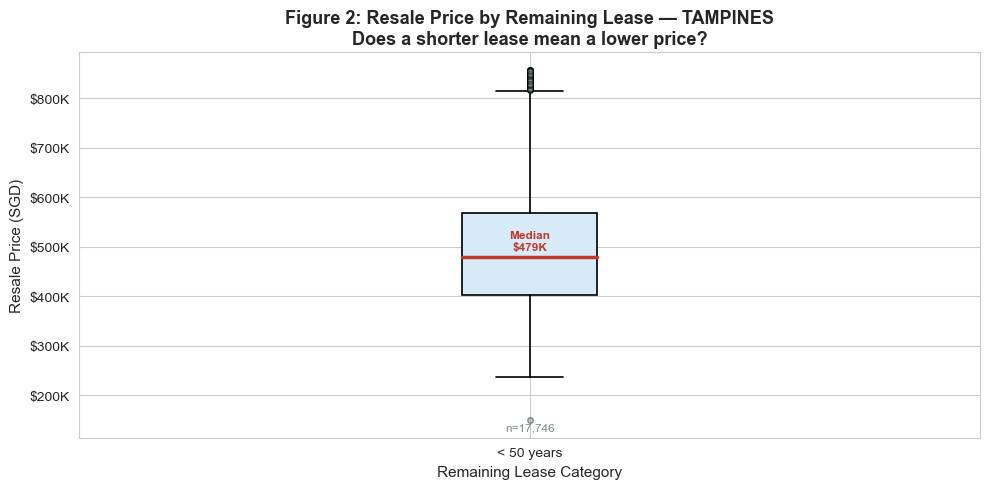

✅ Chart saved → charts/Figure2_Q2_LeaseDepreciation.png

📖 How to read a box plot:
   • Red line = median price (middle value)
   • Box edges = 25th and 75th percentile (middle 50% of transactions)
   • Whiskers = typical range (1.5 × IQR)
   • Dots = outliers (unusually high or low transactions)


In [16]:
# ── Choose your focus town for Q2 ─────────────────────────────
# Pick a town with enough data in at least 3 lease brackets
# Run this cell first to see which towns work best

lease_coverage = (
    hdb.groupby(['town', 'lease_bracket'])
    .size()
    .unstack(fill_value=0)
)
# Count how many brackets each town has with ≥30 transactions
lease_coverage['brackets_with_data'] = (lease_coverage >= 30).sum(axis=1)
good_towns = lease_coverage[lease_coverage['brackets_with_data'] >= 3].sort_values(
    'brackets_with_data', ascending=False
)

print('Towns with data in 3+ lease brackets (good candidates for Q2):')
print(good_towns[['brackets_with_data']].head(10).to_string())
print('\n→ Pick one of these towns for FOCUS_TOWN below')

# ── Q2: Set your focus town ───────────────────────────────────
FOCUS_TOWN = 'TAMPINES'   # ← CHANGE to your chosen town

town_df       = hdb[hdb['town'] == FOCUS_TOWN].copy()
BRACKET_ORDER = ['< 50 years', '50–69 years', '70–89 years', '90+ years']
BRACKET_ORDER = [b for b in BRACKET_ORDER if b in town_df['lease_bracket'].unique()]

# Summary statistics per lease bracket
lease_summary = (
    town_df.groupby('lease_bracket')['resale_price']
    .agg(['median', 'mean', 'count', 'std'])
    .reindex(BRACKET_ORDER)
    .round(0)
)
lease_summary.columns = ['Median', 'Mean', 'Count', 'Std_Dev']

print(f'Q2 Results: Resale Price by Lease Bracket — {FOCUS_TOWN}')
print('=' * 60)
print(lease_summary.to_string())

# ── Key insight numbers ────────────────────────────────────────
if '90+ years' in lease_summary.index and '< 50 years' in lease_summary.index:
    high_median = lease_summary.loc['90+ years',  'Median']
    low_median  = lease_summary.loc['< 50 years', 'Median']
    diff        = high_median - low_median
    pct_premium = diff / low_median * 100
    print(f'\n💡 90+ year lease median: ${high_median:,.0f}')
    print(f'💡 <50 year lease median: ${low_median:,.0f}')
    print(f'💡 Long lease premium:    ${diff:,.0f} ({pct_premium:.1f}% more expensive)')

    # ── Q2: Box Plot ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

data_groups = [
    town_df[town_df['lease_bracket'] == b]['resale_price'].values
    for b in BRACKET_ORDER
]

bp = ax.boxplot(
    data_groups,
    labels       = BRACKET_ORDER,
    patch_artist = True,
    medianprops  = dict(color=C_RED,   linewidth=2.5),
    boxprops     = dict(facecolor='#D6EAF8', linewidth=1.2),
    whiskerprops = dict(linewidth=1.2),
    capprops     = dict(linewidth=1.2),
    flierprops   = dict(marker='o', markerfacecolor=C_GREY,
                        markersize=4, linestyle='none', alpha=0.4)
)

# Annotate medians
y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
for i, group_data in enumerate(data_groups):
    if len(group_data) > 0:
        med = np.median(group_data)
        ax.text(i + 1, med + y_range * 0.02,
                f'Median\n${med/1000:.0f}K',
                ha='center', fontsize=8.5,
                color=C_RED, fontweight='bold')

# Sample sizes
for i, b in enumerate(BRACKET_ORDER):
    n = len(town_df[town_df['lease_bracket'] == b])
    ax.text(i + 1, ax.get_ylim()[0] + y_range * 0.02,
            f'n={n:,}', ha='center', fontsize=8.5, color=C_GREY)

ax.set_title(
    f'Figure 2: Resale Price by Remaining Lease — {FOCUS_TOWN}\n'
    'Does a shorter lease mean a lower price?'
)
ax.set_xlabel('Remaining Lease Category')
ax.set_ylabel('Resale Price (SGD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('charts/Figure2_Q2_LeaseDepreciation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved → charts/Figure2_Q2_LeaseDepreciation.png')

print('\n📖 How to read a box plot:')
print('   • Red line = median price (middle value)')
print('   • Box edges = 25th and 75th percentile (middle 50% of transactions)')
print('   • Whiskers = typical range (1.5 × IQR)')
print('   • Dots = outliers (unusually high or low transactions)')


📝 Q2 Written Findings — Complete This for Your Report
Double-click this cell and fill in the blanks.

Finding:
In [FOCUS_TOWN], flats with 90+ years of remaining lease have a median resale price of $[___], compared

The box plot (Figure 2) shows a clear step-down in median prices as the remaining lease shortens. The 50–69 year bracket has a median of $[___], suggesting a mid-range option for budget-conscious buyers.

Business Recommendation:
Buyers with tight budgets who plan to live in the flat for 10–15 years may consider the 50–69 year lease bracket in [FOCUS_TOWN], potentially saving $[___] compared to a new or long-lease flat. However, buyers planning to resell should note that shorter-lease flats have reduced future resale value and CPF usage restrictions apply to flats with fewer than 30 years remaining on the lease.


---
## Are prices going up or down?

Q3: Are prices going up or down?

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Business Question: Is HDB resale a good long-term investment? What is the annual growth rate?

Method: Annual median price → line chart → CAGR (Compound Annual Growth Rate)
Chart: Line chart with annotated start/end prices and CAGR callout box
New skill: CAGR formula — expresses growth as a single annual percentage

---
> 🧠 **Reflection :** If prices went from \$300K in 2012 to \$560K in 2024, what does that mean for a buyer who bought in 2012? Calculate mentally before we code it.

In [17]:
# ── Q3: Annual price trend + CAGR ─────────────────────────────
annual = (
    hdb.groupby('year')['resale_price']
    .agg(Median_Price='median', Mean_Price='mean', Transactions='count')
    .round(0)
    .reset_index()
)

# CAGR calculation
START_YEAR  = annual['year'].min()
END_YEAR    = annual['year'].max()
start_price = annual.loc[annual['year'] == START_YEAR, 'Median_Price'].values[0]
end_price   = annual.loc[annual['year'] == END_YEAR,   'Median_Price'].values[0]
n_years     = END_YEAR - START_YEAR
cagr        = ((end_price / start_price) ** (1 / n_years) - 1) * 100
total_growth= (end_price / start_price - 1) * 100
abs_gain    = end_price - start_price

print('Q3 Results: Annual Median Resale Price')
print('=' * 60)
print(annual.to_string(index=False))
print()
print(f'💡 Start ({START_YEAR}):    ${start_price:,.0f}')
print(f'💡 End   ({END_YEAR}):    ${end_price:,.0f}')
print(f'💡 Absolute gain:  +${abs_gain:,.0f}')
print(f'💡 Total growth:   +{total_growth:.1f}% over {n_years} years')
print(f'💡 CAGR:           {cagr:.2f}% per year')
print(f'\n📐 CAGR = (({end_price:.0f}/{start_price:.0f})^(1/{n_years}) - 1) × 100 = {cagr:.2f}%')

NameError: name 'EFJWEJKSFJKFJKWF' is not defined

In [ ]:
# ── Q3: Line Chart with CAGR annotation ───────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(annual['year'], annual['Median_Price'],
        color=C_BLUE, linewidth=2.5, marker='o', markersize=7, zorder=3)
ax.fill_between(annual['year'], annual['Median_Price'],
                alpha=0.08, color=C_BLUE)

# Year-over-year annotations
for _, row in annual.iterrows():
    ax.text(row['year'], row['Median_Price'] + (annual['Median_Price'].max() * 0.015),
            f"${row['Median_Price']/1000:.0f}K",
            ha='center', fontsize=7.5, color=C_BLUE)

# CAGR callout box
ax.text(0.03, 0.92,
        f'CAGR {START_YEAR}–{END_YEAR}: {cagr:.1f}%/yr\n'
        f'Total growth: +{total_growth:.0f}%\n'
        f'(${start_price/1000:.0f}K → ${end_price/1000:.0f}K)',
        transform=ax.transAxes,
        fontsize=10, fontweight='bold', va='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#FEF9E7',
                  edgecolor=C_RED, linewidth=1.5)
       )

ax.set_title(
    f'Figure 3: HDB Median Resale Price Trend ({START_YEAR}–{END_YEAR})\n'
    'Is HDB a good long-term investment?'
)
ax.set_xlabel('Year')
ax.set_ylabel('Median Resale Price (SGD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_xticks(annual['year'])
plt.xticks(rotation=45)
ax.set_xlim(START_YEAR - 0.5, END_YEAR + 0.5)

plt.tight_layout()
plt.savefig('charts/Figure3_Q3_PriceTrend.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved → charts/Figure3_Q3_PriceTrend.png')

### 📝 Q3 Written Findings 

**Double-click this cell and fill in the blanks.**

---

**Finding:**  
HDB resale prices grew from **$[start]** in **[start year]** to **$[end]** in **[end year]**, representing a Compound Annual Growth Rate (CAGR) of **[X]%** per year and total appreciation of **[Y]%** over **[Z] years**.

**[If prices dipped in any year, note it here]** For example, a notable decline was observed in **[year]**, likely attributable to *[e.g., government cooling measures / economic uncertainty / COVID-19].*

The overall growth rate of **[X]%** per year **[outperforms / underperforms]** Singapore's average CPI inflation of approximately 2% per year, suggesting that HDB resale flats have historically been a **[positive / negative]** real-terms store of value.

**Business Recommendation:**  
Based on the **[X]%** annual CAGR, a buyer who purchased at **$[start price]** in **[start year]** and held the property to **[end year]** would have gained approximately **$[gain]** in paper value — a **[Y]%** return. This supports HDB ownership as a viable long-term wealth-building strategy for Singaporean households, **provided they can hold the property for 10+ years** and account for transaction costs, renovation, and government restrictions on early resale.

---
## Any geographic differences?

> Does living in the "Central" region command a premium?

In [ ]:
# ── Q4: Regional analysis ─────────────────────────────────────
region_stats = (
    hdb.groupby('region')
    .agg(
        Median_Price         = ('resale_price',  'median'),
        Median_Price_per_sqm = ('price_per_sqm', 'median'),
        Mean_Price           = ('resale_price',  'mean'),
        Transactions         = ('resale_price',  'count')
    )
    .round(0)
    .sort_values('Median_Price', ascending=False)
    .reset_index()
)

print('Q4 Results: Resale Price by Region')
print('=' * 60)
print(region_stats.to_string(index=False))

# ── Key insight numbers ────────────────────────────────────────
central_row   = region_stats[region_stats['region'] == 'Central']
cheapest_row  = region_stats.iloc[-1]

if not central_row.empty:
    central_price  = central_row['Median_Price'].values[0]
    cheapest_price = cheapest_row['Median_Price']
    premium_abs    = central_price - cheapest_price
    premium_pct    = (central_price / cheapest_price - 1) * 100
    print(f'\n💡 Central median price:        ${central_price:,.0f}')
    print(f'💡 Cheapest region ({cheapest_row["region"]}): ${cheapest_price:,.0f}')
    print(f'💡 Central premium:             +${premium_abs:,.0f} ({premium_pct:.1f}% higher)')

In [ ]:
# ── Q4: Side-by-side chart ────────────────────────────────────
# Left: raw median price  |  Right: price per sqm (size-adjusted)

region_order_price  = region_stats.sort_values('Median_Price', ascending=False)['region'].tolist()
region_order_ppsqm  = region_stats.sort_values('Median_Price_per_sqm', ascending=False)['region'].tolist()

def get_region_colors(order):
    return [REGION_COLORS.get(r, C_GREY) for r in order]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: Median Resale Price ─────────────────────────────────
ax = axes[0]
rs_price = region_stats.set_index('region').reindex(region_order_price)
colors_l = get_region_colors(region_order_price)
bars = ax.bar(region_order_price, rs_price['Median_Price'],
              color=colors_l, edgecolor='white', linewidth=0.8)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + rs_price['Median_Price'].max() * 0.01,
            f'${bar.get_height()/1000:.0f}K',
            ha='center', fontsize=9.5, fontweight='bold')
ax.set_title('Median Resale Price by Region', fontsize=11)
ax.set_ylabel('Median Resale Price (SGD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_ylim(0, rs_price['Median_Price'].max() * 1.18)

# ── Right: Price per sqm (controls for flat size) ────────────
ax = axes[1]
rs_ppsqm  = region_stats.set_index('region').reindex(region_order_ppsqm)
colors_r  = get_region_colors(region_order_ppsqm)
bars2 = ax.bar(region_order_ppsqm, rs_ppsqm['Median_Price_per_sqm'],
               color=colors_r, edgecolor='white', linewidth=0.8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + rs_ppsqm['Median_Price_per_sqm'].max() * 0.01,
            f'${bar.get_height():,.0f}',
            ha='center', fontsize=9.5, fontweight='bold')
ax.set_title('Median Price per sqm by Region\n(controls for flat size)', fontsize=11)
ax.set_ylabel('Median Price per sqm (SGD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_ylim(0, rs_ppsqm['Median_Price_per_sqm'].max() * 1.18)

# Region colour legend
legend_handles = [mpatches.Patch(color=v, label=k) for k, v in REGION_COLORS.items()
                  if k in region_stats['region'].values]
axes[1].legend(handles=legend_handles, loc='upper right', fontsize=8.5, title='Region')

plt.suptitle(
    f'Figure 4: Does the Central Region Command a Price Premium? ({START_YEAR}–{END_YEAR})',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('charts/Figure4_Q4_RegionalPremium.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved → charts/Figure4_Q4_RegionalPremium.png')

### 📝 Q4 Written Findings

---

**Finding:**  
The **Central** region commands the highest median resale price at **$[___]** 

**[North-East / East / West / North]** region offers the best balance of price and accessibility, with median prices of **$[___]** and good MRT connectivity.

**Business Recommendation:**  
The data confirms that the Central region commands a consistent and significant premium over all other regions — primarily driven by proximity to employment hubs, transport networks, and amenities. Buyers who work in the CBD but can tolerate a **30–45 minute commute** would achieve materially better value in the **[recommended region]** region, potentially saving **$[___]** or more on a comparable flat.

---